# Assignment #1

1. Write your own functions to zoom the given images to be four times as big and to shrink
   the given images to be a quarter of their size using replication.
   Note: You have to convert color images to gray scale images using any built-in function. Do
   not use any built-in functions to zoom and shrink an image.
  (Use images from the following files to test your program: flowers.jpg, cartoon.jpg,
  kittens.jpg, and cherry_tree.jpg.)

In [1]:
import numpy as np
import cv2 as cv
import os
from matplotlib import pyplot as plt

In [2]:
def imshow(img):
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    # plt.axis('off')
    plt.show()

In [3]:
imgs = []
# Read files from ./assets
for file in os.listdir('./assets'):
    if file.endswith('.jpg') or file.endswith('.png'):
        img = cv.imread(os.path.join('./assets', file))
        imgs.append(img)

## Scale up using replication method

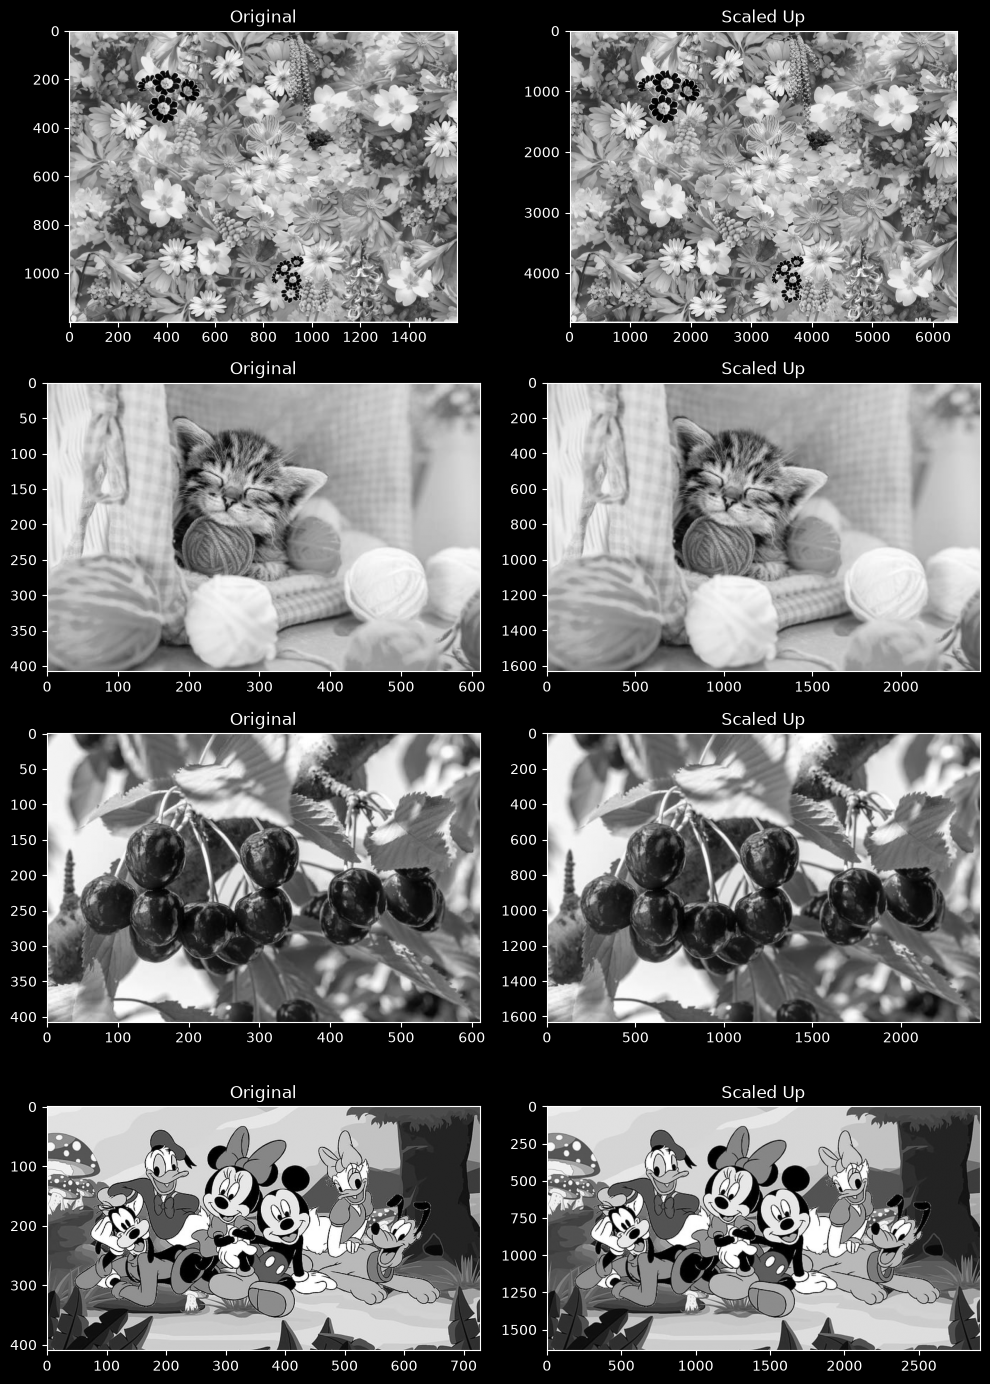

In [4]:
fig, axs = plt.subplots(nrows=len(imgs), ncols=2, figsize=(10, 14))

def scale_up_img_replication(img, times: int):
  shape_y, shape_x = img.shape
  new_shape_y, new_shape_x = shape_y * times, shape_x * times
  new_img = np.zeros((new_shape_y, new_shape_x), dtype=np.uint8)
  for y in range(new_shape_y):
    for x in range(new_shape_x):
      # Pixel replication
      new_img[y, x] = img[y // times, x // times]
  
  return new_img

for r in range(len(imgs)):
  img = imgs[r]
  gray_scaled_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  axs[r, 0].imshow(gray_scaled_img, cmap='gray')
  axs[r, 0].set_title("Original")

  scaled_up_img = scale_up_img_replication(gray_scaled_img, 4)
  axs[r, 1].imshow(scaled_up_img, cmap='gray')
  axs[r, 1].set_title("Scaled Up")

plt.tight_layout()
plt.show()

## Scale down using nearest neighbour method

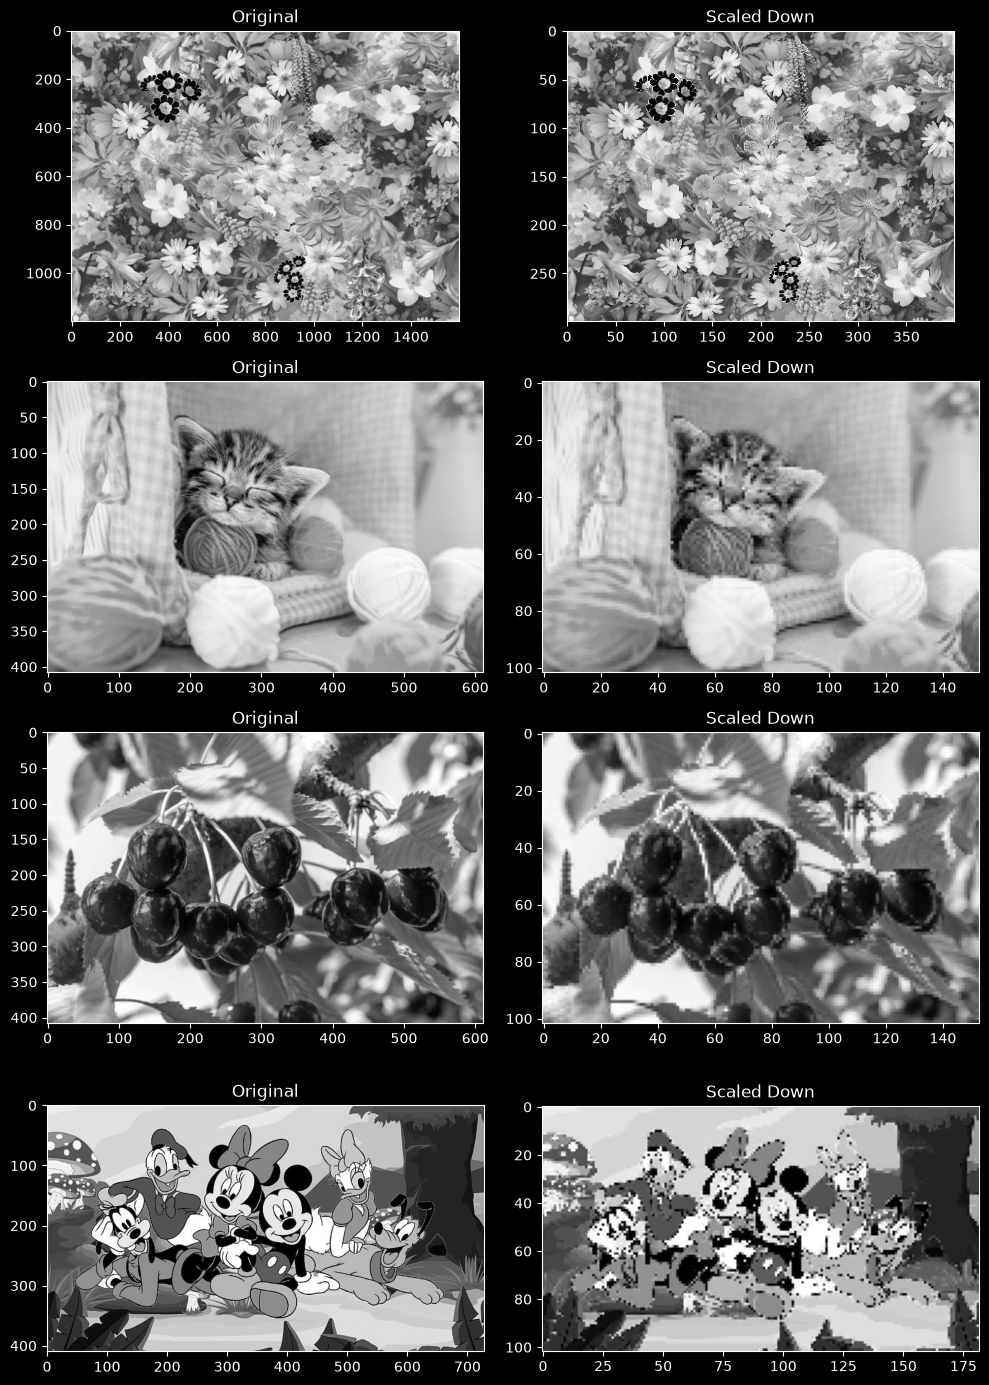

In [5]:
fig, axs = plt.subplots(nrows=len(imgs), ncols=2, figsize=(10, 14))

def scale_down_img_replication(img, factor: int):
  shape_y, shape_x = img.shape
  new_shape_y, new_shape_x = shape_y // factor, shape_x // factor
  new_img = np.zeros((new_shape_y, new_shape_x), dtype=np.uint8)
  for y in range(new_shape_y):
    for x in range(new_shape_x):
      # sample the pixel from the original image
      new_img[y, x] = img[y * factor, x * factor]
  
  return new_img

for r in range(len(imgs)):
  img = imgs[r]
  gray_scaled_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  axs[r, 0].imshow(gray_scaled_img, cmap='gray')
  axs[r, 0].set_title("Original")

  scaled_down_img = scale_down_img_replication(gray_scaled_img, 4) # 1/4
  axs[r, 1].imshow(scaled_down_img, cmap='gray')
  axs[r, 1].set_title("Scaled Down")
  
plt.tight_layout()
plt.show()

## Bit reduction
2. Write a program to reduce the 8-bit gray scale images to 1-bit, 3-bit, and 6-bit images.
   Note: Do not use any built-in functions to quantize the gray levels. You have to write your
   own program.
   (Use images from the following files to test your program: flowers.jpg, cartoon.jpg,
   kittens.jpg, and cherry_tree.jpg.)

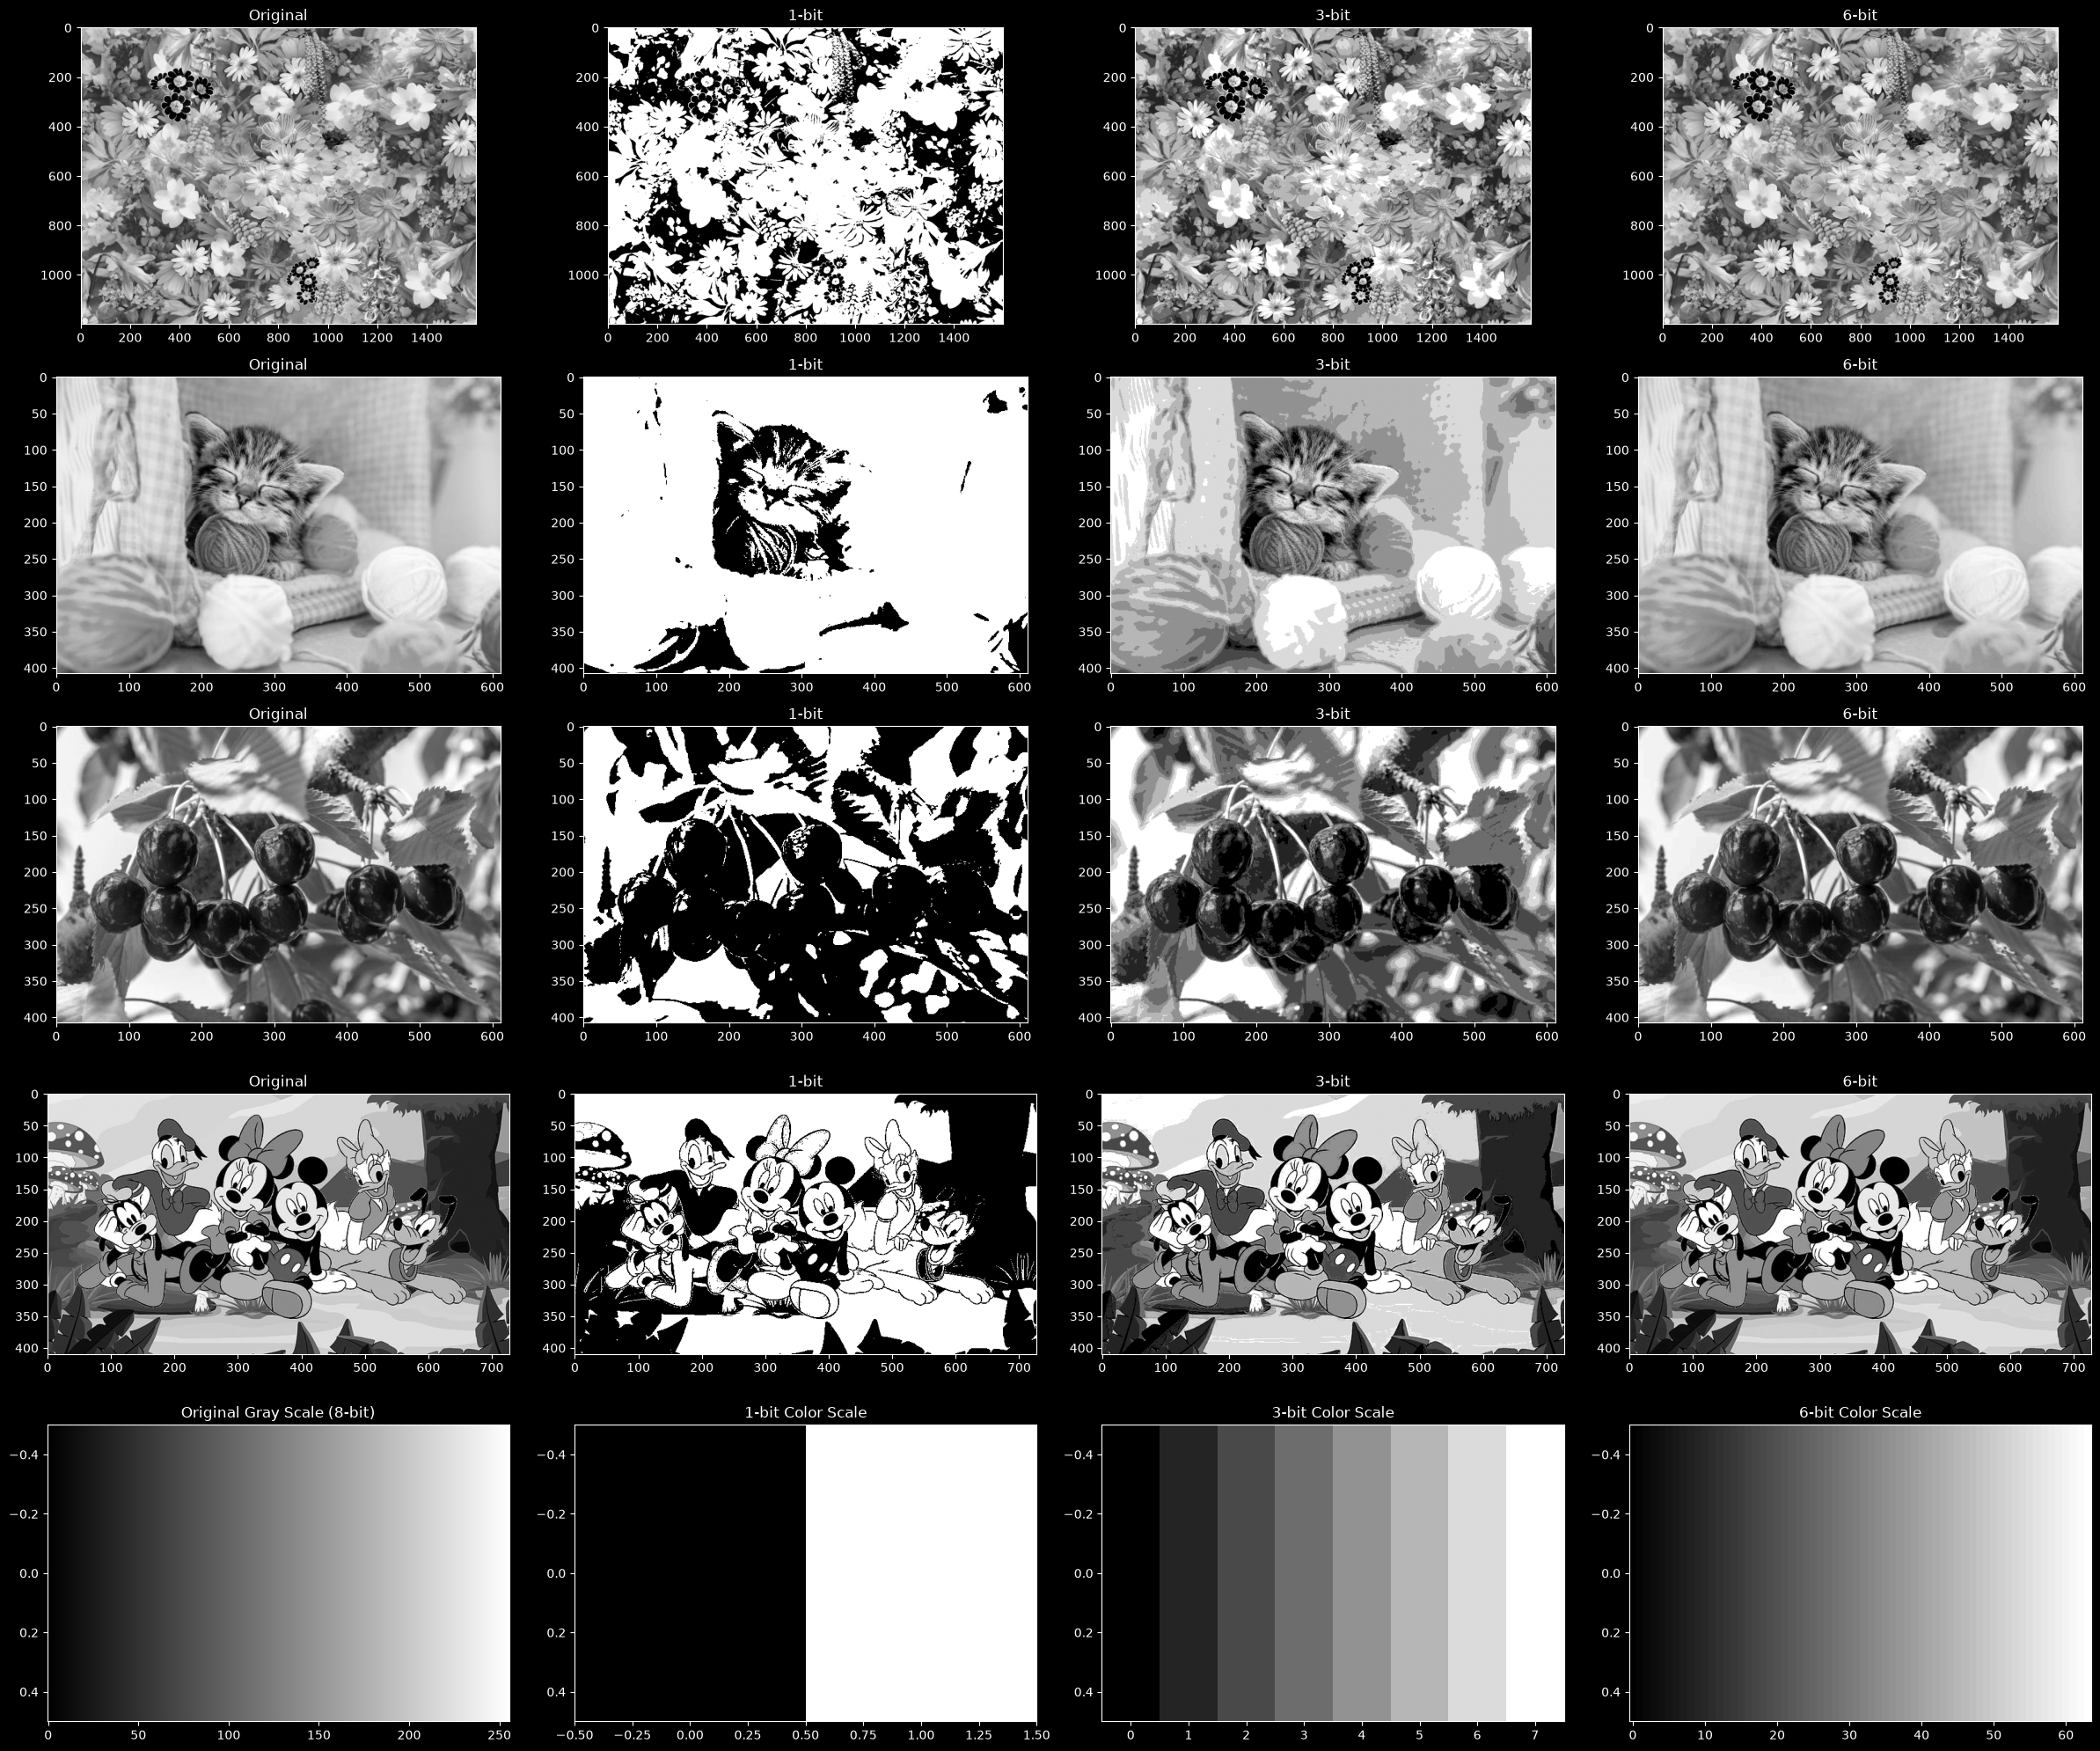

In [6]:
fig, axs = plt.subplots(nrows=len(imgs) + 1, ncols=4, figsize=(24, 20))

def bit_reduction(img, target_bits):
    levels = 2 ** target_bits
    output = np.zeros_like(img, dtype=np.uint8)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            value = int(img[y, x])

            # Convert 0–255 to one of 2^target_bits levels
            level = (value * levels) // 256
            level = min(level, levels - 1)

            # Map levels back to 0–255 for display
            output[y, x] = (level * 255) // (levels - 1)

    return output

for r in range(len(imgs)):
  img = imgs[r]
  gray_scaled_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  axs[r, 0].imshow(gray_scaled_img, cmap='gray')
  axs[r, 0].set_title("Original")

  scaled_down_img = bit_reduction(gray_scaled_img, 1) # 1-bit
  axs[r, 1].imshow(scaled_down_img, cmap='gray')
  axs[r, 1].set_title("1-bit")

  scaled_down_img = bit_reduction(gray_scaled_img, 3) # 3-bit
  axs[r, 2].imshow(scaled_down_img, cmap='gray')
  axs[r, 2].set_title("3-bit")

  scaled_down_img = bit_reduction(gray_scaled_img, 6) # 6-bit
  axs[r, 3].imshow(scaled_down_img, cmap='gray')
  axs[r, 3].set_title("6-bit")

axs[4, 0].imshow(np.arange(256).reshape(1, 256), cmap='gray', aspect='auto')
axs[4, 0].set_title("Original Gray Scale (8-bit)")
# 1-bit color scale
axs[4, 1].imshow(np.array([[0, 255]]), cmap='gray', aspect='auto')
axs[4, 1].set_title("1-bit Color Scale")
# 3-bit color scale
axs[4, 2].imshow(np.array([np.arange(0, 256, 2**5)]), cmap='gray', aspect='auto')
axs[4, 2].set_title("3-bit Color Scale")
# 6-bit color scale
axs[4, 3].imshow(np.array([np.arange(0, 256, 2**2)]), cmap='gray', aspect='auto')
axs[4, 3].set_title("6-bit Color Scale")

plt.tight_layout()
plt.show()